#  Notebook 3 — Modelo Sesgado
## HMDA New York 2024: Sesgo, Equidad y Explicabilidad en Hipotecas

**Autores:** Izan Cuesta Corbí · Dennis García Solera · Marcos Segurado Llopis · Jesús Cano Moya  
**Dataset:** Home Mortgage Disclosure Act (HMDA) — New York 2024 (CFPB)

---
> **Objetivo de este notebook:** Comparar y optimizar modelos de ensamble para seleccionar el mejor predictor. Evaluaremos su rendimiento, cuantificaremos su sesgo inherente hacia grupos sensibles y auditaremos sus decisiones mediante valores SHAP.

> `RANDOM_STATE = 42` fijado globalmente para reproducibilidad.

--- 

### Imports

In [32]:
import pandas as pd
import time
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

---
---

## Conjunto de Datos

En este notebook hemos cargado los conjuntos de entrenamiento y test generados en el Notebook 1, ya preprocesados, imputados y escalados. Al partir de los mismos datos que el baseline, garantizamos que cualquier diferencia en los resultados sea atribuible exclusivamente al modelo utilizado y no al preprocesamiento.

---

### Carga del dataset

In [7]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.head()

Train: (226665, 81)
Test:  (56667, 81)


,derived_msa-md,county_code,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,loan_amount,...,derived_race_Black or African American,derived_race_Free Form Text Only,derived_race_Joint,derived_race_Native Hawaiian or Other Pacific Islander,derived_race_Race Not Available,derived_race_White,derived_sex_Female,derived_sex_Joint,derived_sex_Male,derived_sex_Sex Not Available
0,-0.053043,-0.136364,0.0,0.0,9.666667,1.0,0.0,1.0,0.0,-0.030303,...,False,False,False,False,False,True,False,True,False,False
1,5.598696,0.772727,0.0,0.0,-0.333333,0.0,0.0,0.0,0.0,-0.303030,...,False,False,False,False,False,True,False,False,True,False
2,-1.898609,-1.318182,0.0,0.0,0.666667,1.0,0.0,0.0,0.0,-0.545455,...,False,False,False,False,False,True,False,True,False,False
3,0.414435,-0.227273,0.0,0.0,-0.333333,0.0,0.0,0.0,1.0,-0.272727,...,False,False,False,False,True,False,False,False,False,True
4,0.000000,0.363636,0.0,0.0,9.666667,0.0,0.0,0.0,1.0,0.696970,...,False,False,False,False,True,False,True,False,False,False


---
### Selección de Columnas

A diferencia del Notebook 2, en este caso hemos incluido todas las columnas disponibles como features, incluyendo los atributos sensibles (`derived_race_*`, `derived_sex_*`, `derived_ethnicity_*`). El objetivo es evaluar el comportamiento natural de los modelos de ensamble sin ninguna restricción, para identificar el sesgo inherente que introducen cuando tienen acceso a información demográfica.

In [8]:
FEATURE_COLS = [col for col in train.columns if col != 'action_taken']
print(f"Nº de features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Nº de features: 80
Features: ['derived_msa-md', 'county_code', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_term', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'income', 'debt_to_income_ratio', 'applicant_credit_score_type', 'co-applicant_credit_score_type', 'applicant_ethnicity-1', 'co-applicant_ethnicity-1', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race-1', 'co-applicant_race-1', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex', 'co-applicant_sex', 'applicant_sex_observed', 'co-applicant_sex_observed', 'applicant_age', 'applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'aus-1

---
### Separación de Train/Test

In [9]:
X_train = train[FEATURE_COLS] # columnas que entran al modelo 
y_train = train['action_taken'] # columna que queremos predecir

X_test = test[FEATURE_COLS] 
y_test = test['action_taken'] 

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (226665, 80)
X_test:  (56667, 80)


---
---

## Comparativa de Modelos

Para abordar este problema de clasificación binaria, descartaremos algoritmos simples como los Árboles de Decisión por su tendencia al sobreajuste, y enfoques como Support Vector Machines (SVM) por su inasumible coste computacional frente a matrices dispersas de este tamaño. 

Nuestra estrategia se centrará exclusivamente en modelos de ensamble basados en árboles (estándar actual para datos tabulares). Para seleccionar el mejor modelo evaluaremos dos arquitecturas: por un lado, el paradigma *Bagging* (entrenamiento paralelo) mediante **Random Forest**, que reduce la varianza construyendo árboles independientes y promediando sus decisiones. Por otro lado, contrastaremos este enfoque con la familia *Boosting* (entrenamiento secuencial), donde cada nuevo árbol corrige iterativamente los errores del anterior. Dentro de esta segunda rama evaluaremos el modelo base de **Gradient Boosting** frente a sus evoluciones más avanzadas: **XGBoost**, que incorpora regularización matemática para un ajuste más robusto, y **LightGBM**, que optimiza la construcción de las ramas logrando una eficiencia computacional máxima en *datasets* voluminosos.

In [10]:
mejores_resultados = []

---

### Random Forest

El Random Forest es un modelo de ensamble basado en *Bagging* que construye múltiples árboles de decisión de forma independiente y paralela, cada uno entrenado sobre un subconjunto aleatorio de datos y features. La predicción final se obtiene promediando las probabilidades de todos los árboles, lo que reduce la varianza y mejora la generalización respecto a un único árbol de decisión.

In [11]:
resultados_rf = []

#### Modelo por defecto

Entrenamos primero el modelo con sus parámetros por defecto para establecer una referencia base antes de la optimización.

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

resultados_rf.append({
    'Modelo': 'RF por defecto',
    'Accuracy': round(accuracy_score(y_test, y_pred_rf), 4),
    'F1-Score': round(f1_score(y_test, y_pred_rf), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_rf), 4)
})

print(f"Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.56      0.67     14909
           1       0.86      0.96      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.85      0.76      0.79     56667
weighted avg       0.85      0.86      0.85     56667



#### Optimización por GridSearch

Exploramos combinaciones de los parámetros más influyentes del Random Forest. `n_estimators` controla el número de árboles, `max_features` el número de features consideradas en cada split, `max_depth` la profundidad máxima de cada árbol y `min_samples_leaf` el número mínimo de muestras en cada hoja. Usamos `roc_auc` como métrica de optimización por ser el estándar en la industria financiera para problemas de clasificación con desbalance.

In [13]:
param_grid = {
    'n_estimators':     [100, 200],
    'max_features':     ['sqrt', 'log2', None],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

start = time.time()
grid_rf.fit(X_train, y_train)
elapsed = time.time() - start

# Mejor modelo
y_pred_grid_rf = grid_rf.best_estimator_.predict(X_test)
y_prob_grid_rf = grid_rf.best_estimator_.predict_proba(X_test)[:, 1]

resultados_rf.append({
    'Modelo': 'RF Optimizado',
    'Accuracy': round(accuracy_score(y_test, y_pred_grid_rf), 4),
    'F1-Score': round(f1_score(y_test, y_pred_grid_rf), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_grid_rf), 4),
    'Tiempo (s)': round(elapsed, 2)
})

print(f"Mejores parámetros: {grid_rf.best_params_}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_grid_rf))

Mejores parámetros: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 200}

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.56      0.68     14909
           1       0.86      0.97      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.86      0.76      0.79     56667
weighted avg       0.86      0.86      0.85     56667



#### Mejor modelo Random Forest

Seleccionamos la configuración con mayor ROC-AUC y la registramos en la lista de mejores modelos para la comparativa final.

In [14]:
comparacion_rf = pd.DataFrame(resultados_rf).set_index('Modelo')
display(comparacion_rf)

,Accuracy,F1-Score,ROC-AUC,Tiempo (s)
Modelo,,,,
RF por defecto,0.8564,0.9080,0.8746,NaN
RF Optimizado,0.8601,0.9106,0.8792,3015.35


In [15]:
mejor_rf_nombre = comparacion_rf['ROC-AUC'].idxmax()  # 'RF por defecto' o 'RF Optimizado'
mejor_rf_model  = grid_rf.best_estimator_ if 'Optimizado' in mejor_rf_nombre else rf

mejor_rf = comparacion_rf.loc[mejor_rf_nombre].to_dict()
mejor_rf['Modelo'] = 'Random Forest'
mejores_resultados.append(mejor_rf)

---
### Gradient Boosting

El Gradient Boosting es un modelo de ensamble basado en *Boosting* que construye árboles de forma secuencial, donde cada nuevo árbol se entrena para corregir los errores del anterior. A diferencia del Random Forest, los árboles no son independientes sino que se construyen de forma iterativa. Esta naturaleza secuencial lo hace más preciso que el Random Forest pero también más lento y sensible a los hiperparámetros.

In [16]:
resultados_gb = []

#### Modelo por defecto

Entrenamos primero el modelo con sus parámetros por defecto para establecer una referencia base antes de la optimización.

In [17]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

resultados_gb.append({
    'Modelo': 'GB por defecto',
    'Accuracy': round(accuracy_score(y_test, y_pred_gb), 4),
    'F1-Score': round(f1_score(y_test, y_pred_gb), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_gb), 4)
})

print("Classification Report:\n")
print(classification_report(y_test, y_pred_gb))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.47      0.60     14909
           1       0.84      0.97      0.90     41758

    accuracy                           0.84     56667
   macro avg       0.84      0.72      0.75     56667
weighted avg       0.84      0.84      0.82     56667



#### Optimización por GridSearch

Exploramos las combinaciones más relevantes de hiperparámetros. `n_estimators` controla el número de árboles secuenciales, `max_depth` la complejidad de cada 
árbol individual, `learning_rate` la contribución de cada árbol al modelo final (valores bajos requieren más árboles pero generalizan mejor) y `subsample` la fracción de datos usada en cada iteración, que introduce aleatoriedad y reduce el sobreajuste.

In [18]:
# Optimización por GridSearch
param_grid_gb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid_gb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_gb.fit(X_train, y_train)
elapsed = time.time() - start

y_pred_grid_gb = grid_gb.best_estimator_.predict(X_test)
y_prob_grid_gb = grid_gb.best_estimator_.predict_proba(X_test)[:, 1]

resultados_gb.append({
    'Modelo': 'GB Optimizado',
    'Accuracy': round(accuracy_score(y_test, y_pred_grid_gb), 4),
    'F1-Score': round(f1_score(y_test, y_pred_grid_gb), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_grid_gb), 4),
    'Tiempo (s)': round(elapsed, 2)
})

print(f"Mejores parámetros: {grid_gb.best_params_}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_grid_gb))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.58      0.69     14909
           1       0.87      0.96      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.86      0.77      0.80     56667
weighted avg       0.86      0.86      0.85     56667



#### Mejor modelo Gradient Boosting

Seleccionamos la configuración con mayor ROC-AUC y la registramos en la lista de mejores modelos para la comparativa final.

In [19]:
# Mejor modelo Gradient Boosting
comparacion_gb = pd.DataFrame(resultados_gb).set_index('Modelo')
display(comparacion_gb)


,Accuracy,F1-Score,ROC-AUC,Tiempo (s)
Modelo,,,,
GB por defecto,0.8375,0.8978,0.8558,NaN
GB Optimizado,0.8639,0.9126,0.8871,2222.27


In [20]:
# Gradient Boosting
mejor_gb_nombre = comparacion_gb['ROC-AUC'].idxmax()
mejor_gb_model  = grid_gb.best_estimator_ if 'Optimizado' in mejor_gb_nombre else gb


mejor_gb = comparacion_gb.loc[comparacion_gb['ROC-AUC'].idxmax()].to_dict()
mejor_gb['Modelo'] = 'Gradient Boosting'
mejores_resultados.append(mejor_gb)

---
### XGBoost

XGBoost (*Extreme Gradient Boosting*) es una evolución optimizada del Gradient Boosting que incorpora regularización L1 y L2 directamente en la función de pérdida, lo que reduce el sobreajuste de forma más controlada. Además, implementa técnicas de paralelización en la construcción de árboles y manejo nativo de valores faltantes.

In [21]:

resultados_xgb = []

#### Modelo por defecto

Entrenamos primero el modelo con sus parámetros por defecto para establecer una referencia base antes de la optimización.

In [22]:
# Modelo por defecto
start = time.time()
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
)
xgb.fit(X_train, y_train)
elapsed = time.time() - start

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

resultados_xgb.append({
    'Modelo': 'XGBoost por defecto',
    'Accuracy': round(accuracy_score(y_test, y_pred_xgb), 4),
    'F1-Score': round(f1_score(y_test, y_pred_xgb), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_xgb), 4),
    'Tiempo (s)': round(elapsed, 2)
})

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.58      0.69     14909
           1       0.87      0.96      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.86      0.77      0.80     56667
weighted avg       0.86      0.86      0.85     56667



#### Optimización por GridSearch


Además de los parámetros comunes al Gradient Boosting (`n_estimators`, `max_depth`, `learning_rate`, `subsample`), XGBoost incorpora `colsample_bytree`, que controla la fracción de features consideradas en cada árbol de forma análoga a `max_features` en Random Forest. Esta combinación de submuestreo de filas y columnas introduce una doble aleatoriedad que mejora la robustez del modelo.

In [23]:
# Optimización por GridSearch
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_xgb.fit(X_train, y_train)
elapsed = time.time() - start

y_pred_grid_xgb = grid_xgb.best_estimator_.predict(X_test)
y_prob_grid_xgb = grid_xgb.best_estimator_.predict_proba(X_test)[:, 1]

resultados_xgb.append({
    'Modelo': 'XGBoost Optimizado',
    'Accuracy': round(accuracy_score(y_test, y_pred_grid_xgb), 4),
    'F1-Score': round(f1_score(y_test, y_pred_grid_xgb), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_grid_xgb), 4),
    'Tiempo (s)': round(elapsed, 2)
})

print(f"Mejores parámetros: {grid_xgb.best_params_}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_grid_xgb))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.58      0.69     14909
           1       0.86      0.96      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.86      0.77      0.80     56667
weighted avg       0.86      0.86      0.85     56667



#### Mejor modelo XGBoost

Seleccionamos la configuración con mayor ROC-AUC y la registramos en la lista de mejores modelos para la comparativa final.

In [24]:
# Mejor modelo XGBoost
comparacion_xgb = pd.DataFrame(resultados_xgb).set_index('Modelo')
display(comparacion_xgb)

,Accuracy,F1-Score,ROC-AUC,Tiempo (s)
Modelo,,,,
XGBoost por defecto,0.8618,0.9112,0.8847,0.72
XGBoost Optimizado,0.8628,0.9120,0.8875,107.89


In [25]:
# XGBoost
mejor_xgb_nombre = comparacion_xgb['ROC-AUC'].idxmax()
mejor_xgb_model  = grid_xgb.best_estimator_ if 'Optimizado' in mejor_xgb_nombre else xgb


mejor_xgb = comparacion_xgb.loc[comparacion_xgb['ROC-AUC'].idxmax()].to_dict()
mejor_xgb['Modelo'] = 'XGBoost'
mejores_resultados.append(mejor_xgb)

---
### LightGBM

LightGBM (*Light Gradient Boosting Machine*) es la evolución más eficiente de la familia Boosting. A diferencia del Gradient Boosting estándar y XGBoost, que construyen los árboles por niveles (*level-wise*), LightGBM los construye por hojas (*leaf-wise*), eligiendo en cada paso la hoja que mayor reducción de pérdida aporta. Esto lo hace significativamente más rápido y preciso en *datasets* grandes, a costa de ser más propenso al sobreajuste si no se controla correctamente el parámetro `num_leaves`.

In [ ]:
resultados_lgbm = []

#### Modelo por defecto

Entrenamos primero el modelo con sus parámetros por defecto para establecer una referencia base antes de la optimización.

**NOTA:** A diferencia del resto de algoritmos, LightGBM no soporta caracteres especiales (como `:`, `,` o `[]`) en los nombres de las características generadas por el *One-Hot Encoding*, por lo que es obligatorio sustituirlos por guiones bajos antes del entrenamiento.

In [31]:
import re

def limpiar_columnas(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train_lgbm = limpiar_columnas(X_train.copy())
X_test_lgbm  = limpiar_columnas(X_test.copy())

In [ ]:
# Modelo por defecto
start = time.time()
lgbm = LGBMClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
lgbm.fit(X_train_lgbm, y_train)
elapsed = time.time() - start

y_pred_lgbm = lgbm.predict(X_test_lgbm)
y_prob_lgbm = lgbm.predict_proba(X_test_lgbm)[:, 1]

resultados_lgbm.append({
    'Modelo': 'LightGBM por defecto',
    'Accuracy': round(accuracy_score(y_test, y_pred_lgbm), 4),
    'F1-Score': round(f1_score(y_test, y_pred_lgbm), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_lgbm), 4),
    'Tiempo (s)': round(elapsed, 2)
})

print("Classification Report:\n")
print(classification_report(y_test, y_pred_lgbm))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.56      0.68     14909
           1       0.86      0.97      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.86      0.76      0.79     56667
weighted avg       0.86      0.86      0.85     56667



#### Optimización por GridSearch

Además de los parámetros comunes al resto de modelos Boosting, LightGBM incorpora `num_leaves`, que controla el número máximo de hojas por árbol y es el parámetro más determinante de su complejidad. Valores altos permiten capturar patrones más complejos pero aumentan el riesgo de sobreajuste, por lo que se exploran tres niveles: 31 (por defecto), 63 y 127.

In [ ]:
# Optimización por GridSearch
param_grid_lgbm = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
    'num_leaves':    [31, 63, 127]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),
    param_grid_lgbm,
    cv=3,
    scoring='roc_auc',
    n_jobs=1,
    verbose=1
)

start = time.time()
grid_lgbm.fit(X_train_lgbm, y_train)
elapsed = time.time() - start

y_pred_grid_lgbm = grid_lgbm.best_estimator_.predict(X_test_lgbm)
y_prob_grid_lgbm = grid_lgbm.best_estimator_.predict_proba(X_test_lgbm)[:, 1]

resultados_lgbm.append({
    'Modelo': 'LightGBM Optimizado',
    'Accuracy': round(accuracy_score(y_test, y_pred_grid_lgbm), 4),
    'F1-Score': round(f1_score(y_test, y_pred_grid_lgbm), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_grid_lgbm), 4),
    'Tiempo (s)': round(elapsed, 2)
})

print(f"Mejores parámetros: {grid_lgbm.best_params_}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_grid_lgbm))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 127, 'subsample': 0.8}

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.58      0.69     14909
           1       0.86      0.96      0.91     41758

    accuracy                           0.86     56667
   macro avg       0.86      0.77      0.80     56667
weighted avg       0.86      0.86      0.85     56667



#### Mejor modelo LightGBM

Seleccionamos la configuración con mayor ROC-AUC y la registramos en la lista de mejores modelos para la comparativa final.

In [ ]:
# Mejor modelo LightGBM
comparacion_lgbm = pd.DataFrame(resultados_lgbm).set_index('Modelo')
display(comparacion_lgbm)

,Accuracy,F1-Score,ROC-AUC,Tiempo (s)
Modelo,,,,
LightGBM por defecto,0.8590,0.9098,0.8800,1.01
LightGBM Optimizado,0.8621,0.9116,0.8868,319.21


In [ ]:
# LightGBM
mejor_lgbm_nombre = comparacion_lgbm['ROC-AUC'].idxmax()
mejor_lgbm_model  = grid_lgbm.best_estimator_ if 'Optimizado' in mejor_lgbm_nombre else lgbm

mejor_lgbm = comparacion_lgbm.loc[comparacion_lgbm['ROC-AUC'].idxmax()].to_dict()
mejor_lgbm['Modelo'] = 'LightGBM'
mejores_resultados.append(mejor_lgbm)

---
### Guardado de modelos entrenados

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(mejor_rf_model,   '../models/random_forest.pkl')
joblib.dump(mejor_gb_model,   '../models/gradient_boosting.pkl')
joblib.dump(mejor_xgb_model,  '../models/xgboost.pkl')
joblib.dump(mejor_lgbm_model, '../models/lightgbm.pkl')

['../models/lightgbm.pkl']

---
### Comparación

texto: incluimos la Regresion logistica del baseline

In [ ]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

start = time.time()
lr_baseline.fit(X_train, y_train)
elapsed = time.time() - start

y_pred_bs = lr_baseline.predict(X_test)
y_prob_bs = lr_baseline.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva (para ROC-AUC)

mejores_resultados.append({
    'Modelo': 'Baseline',
    'Accuracy': round(accuracy_score(y_test, y_pred_bs), 4),
    'F1-Score': round(f1_score(y_test, y_pred_bs), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_bs), 4),
    'Tiempo (s)': round(elapsed, 2)
})

**Tabla Comparativa**

In [ ]:
comparativa_final = pd.DataFrame(mejores_resultados).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(comparativa_final)

,Modelo,Accuracy,F1-Score,ROC-AUC,Tiempo (s)
0,Gradient Boosting,0.8639,0.9126,0.8871,320.72
1,LightGBM,0.8621,0.9116,0.8868,1.90
2,XGBoost,0.8623,0.9117,0.8864,3.25
3,Random Forest,0.8601,0.9106,0.8792,134.78
4,Baseline,0.7121,0.7877,0.7694,48.85


**Curvas ROC**

In [ ]:
modelos_cargados = {
    'Random Forest':     joblib.load('../models/random_forest.pkl'),
    'Gradient Boosting': joblib.load('../models/gradient_boosting.pkl'),
    'XGBoost':           joblib.load('../models/xgboost.pkl'),
    'LightGBM':          joblib.load('../models/lightgbm.pkl')
}

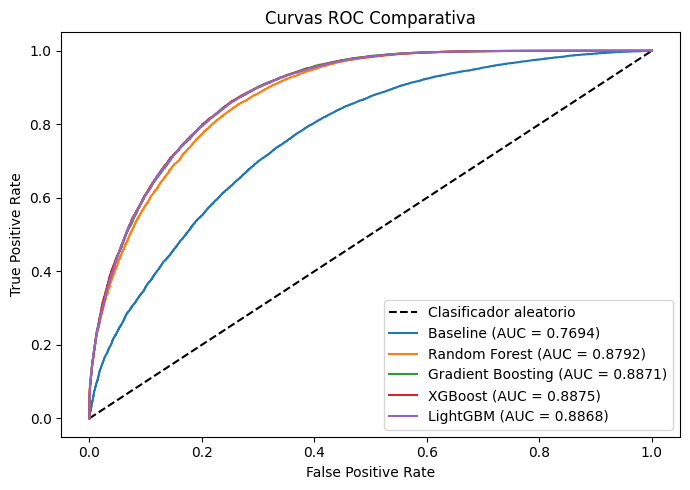

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')

# Baseline
fpr, tpr, _ = roc_curve(y_test, y_prob_bs)
auc_score = roc_auc_score(y_test, y_prob_bs)
plt.plot(fpr, tpr, label=f'Baseline (AUC = {auc_score:.4f})')

# Modelos
for nombre_modelo, modelo in modelos_cargados.items():
    if nombre_modelo == 'LightGBM':
        y_prob = modelo.predict_proba(X_test_lgbm)[:, 1]
    else:
        y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre_modelo} (AUC = {auc_score:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativa')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/images/curva_roc_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

elegido: LIGHTGBM -> con rendimientos muy muy similares, lightgbm es muchisimo mas eficiente a nivel computacional.